In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_excel("Short_Laprida_Sian_TPINTEGRADOR.xlsx",sheet_name="Hoja1",header=1)

In [37]:
df=df.drop(columns={"Unnamed: 0","Unnamed: 1"})

In [38]:
df["Promedio diario de desbloqueo de pantalla"]=pd.to_numeric( df["Promedio diario de desbloqueo de pantalla"],errors="coerce")

In [39]:
df["Promedio diario de desbloqueo de pantalla"]=df["Promedio diario de desbloqueo de pantalla"].fillna(df["Promedio diario de desbloqueo de pantalla"].mean())

In [40]:
horas_promedio_redes=df["Horas promedio en redes sociales"]
print("Variable independiente:",horas_promedio_redes)
rendimiento_academico=df["Rendimiento academico"]
print("Variable dependiente:",rendimiento_academico)

Variable independiente: 0      4.0
1      6.0
2      2.0
3      3.0
4      1.0
      ... 
206    4.1
207    2.5
208    6.3
209    1.5
210    5.3
Name: Horas promedio en redes sociales, Length: 211, dtype: float64
Variable dependiente: 0      7
1      6
2      8
3      5
4      9
      ..
206    8
207    8
208    6
209    8
210    7
Name: Rendimiento academico, Length: 211, dtype: int64


In [41]:
df_2=pd.DataFrame({"X":horas_promedio_redes,"y":rendimiento_academico})

In [42]:
df_2["x*y"]=df_2["X"]*df_2["y"]
df_2["x^2"]=df_2["X"]**2
df_2["y^2"]=df_2["y"]**2

In [43]:
print("\n Tabla de datos")
print(df_2)


 Tabla de datos
       X  y   x*y    x^2  y^2
0    4.0  7  28.0  16.00   49
1    6.0  6  36.0  36.00   36
2    2.0  8  16.0   4.00   64
3    3.0  5  15.0   9.00   25
4    1.0  9   9.0   1.00   81
..   ... ..   ...    ...  ...
206  4.1  8  32.8  16.81   64
207  2.5  8  20.0   6.25   64
208  6.3  6  37.8  39.69   36
209  1.5  8  12.0   2.25   64
210  5.3  7  37.1  28.09   49

[211 rows x 5 columns]


In [44]:
xSum =df_2["X"].sum()
ySum =df_2["y"].sum()
xySum=df_2["x*y"].sum()
x2Sum=df_2["x^2"].sum()
y2Sum=df_2["y^2"].sum()
n=len(df_2)

In [45]:
print("\n Sumatoria")

print("Suma X:", xSum)
print("Suma Y:", ySum)
print("Suma XY:", xySum)
print("Suma X^2:", x2Sum)
print("Suma Y^2:", y2Sum)


 Sumatoria
Suma X: 755.0
Suma Y: 1488
Suma XY: 5097.0
Suma X^2: 3354.84
Suma Y^2: 10884


In [46]:
b=((n * xySum) - (xSum * ySum)) / ((n * x2Sum) - (xSum ** 2))

a = ((ySum * x2Sum) - (xySum * xSum)) / ((n * x2Sum) - (xSum ** 2))
print("\nRecta de regresion")
print(f" y= {a:.2f} + {b:.2f}x")


Recta de regresion
 y= 8.30 + -0.35x


In [47]:
r = ((n * xySum) - (xSum * ySum)) / np.sqrt(((n * x2Sum) - (xSum ** 2)) * ((n * y2Sum) - (ySum ** 2)))
r2=r**2



print("\n Correlacion")
print(f"r ={r:.4f}")
print(f"r^2= {r2:.4f}")


 Correlacion
r =-0.4502
r^2= 0.2027


In [48]:
if r>0:
    print("\n La correlacion es positiva")
elif r<0:
    print("\n La correlacion es negativa")
else:
    print("\n No existe una correlacion")

print(f"El modelo explica aproximadamente el {r2*100:.2f}% de la variabilidad.")


 La correlacion es negativa
El modelo explica aproximadamente el 20.27% de la variabilidad.


In [49]:
x=np.array(horas_promedio_redes)
y=a+b*x

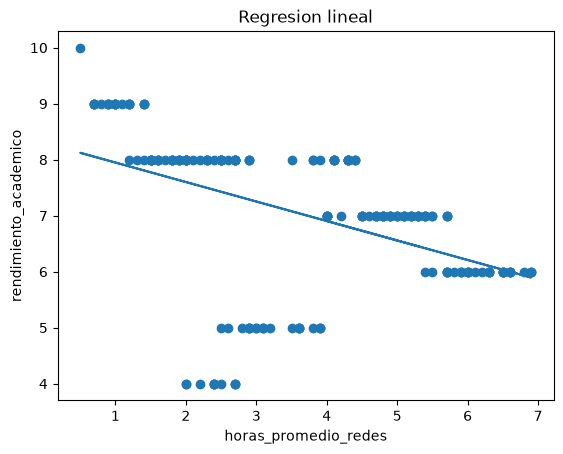

In [50]:
plt.scatter(horas_promedio_redes,rendimiento_academico)
plt.plot(x,y)

plt.title("Regresion lineal")
plt.xlabel("horas_promedio_redes")
plt.ylabel("rendimiento_academico")

plt.show()